# Preprocessing user-provided time series
*Developed by D. Brakenhoff, Artesia, R Caljé, Artesia and R.A. Collenteur, Eawag, January (2021-2023)*

This notebooks shows how to solve the most common errors that arise during the validation of the user provided time series. After showing how to deal with some of the easier errors, we will dive into the topic of making time series equidistant. For this purpose Pastas contains a lot of helper functions.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pastas as ps


## 1. Validating the time series, what is checked?

Let us first look at the docstring of the `ps.validate_stress` method, which can be used to automatically check user-provided input time series. This method is also used internally in Pastas to check all user provided time series. For the stresses `ps.validate_stress` is used and for the oseries the `ps.validate_oseries` is used. The only difference between these methods is that the oseries are not checked for equidistant time series.

In [2]:
?ps.validate_stress

Signature: ps.validate_stress(series: pandas.core.series.Series)
Docstring:
Method to validate user-provided stress input time series.

Parameters
----------
series: pandas.Series
    Pandas.Series object containing the series time series.

Returns
-------
bool:
    True if the series is valid. If not, an error is raised.

Notes
-----
The Series are validated for the following cases:

0. Make sure the series is a Pandas.Series
1. Make sure the values are floats
2. Make sure the index is a DatetimeIndex
3. Make sure the indices are datetime64
4. Make sure the index is monotonically increasing
5. Make sure there are no duplicate indices
6. Make sure the time series has no nan-values
7. Make sure the time series has equidistant time steps

If any of these checks are not passed the method will throw an error that needs
to be fixed by the user.

Examples
--------

>>> ps.validate_stress(series)
File:      c:\users\ezra\appdata\local\miniforge3\envs\pastas_313\lib\site-packages\pastas\timese

### a. If the time series is a DataFrame

In [3]:
index = pd.date_range("2000-01-01", "2000-01-10")
series = pd.DataFrame(data=[np.arange(10.0)], index=index)

# Here's error message returned by Pastas
# ps.validate_stress(series)

In [4]:
series.iloc[:, 0]  # Simply select the first column

2000-01-01    0.0
2000-01-02    0.0
2000-01-03    0.0
2000-01-04    0.0
2000-01-05    0.0
2000-01-06    0.0
2000-01-07    0.0
2000-01-08    0.0
2000-01-09    0.0
2000-01-10    0.0
Freq: D, Name: 0, dtype: float64

### b. If values are not floats

In [8]:
index = pd.date_range("2000-01-01", "2000-01-10")
series = pd.Series(data=range(10), index=index, name="Stress")

# Here's error message returned by Pastas
# ps.validate_stress(series)

In [9]:
# Here is a possible fix to this issue
series = series.astype(float)

### c. If the index is not a datetimeindex

In [10]:
series = pd.Series(data=np.arange(10.0), index=range(10), name="Stress")

# Here's error message returned by Pastas
# ps.validate_stress(series)

In [11]:
# Here is a possible fix to this issue
series.index = pd.to_datetime(series.index)
ps.validate_stress(series)

True

### d. If index is not monotonically increasing

In [13]:
index = pd.to_datetime(["2000-01-01", "2000-01-03", "2000-01-02", "2000-01-4"])
series = pd.Series(data=np.arange(4.0), index=index, name="Stress")

# Here's error message returned by Pastas
# ps.validate_stress(series)

In [14]:
# Here is a possible fix to this issue
series = series.sort_index()
ps.validate_stress(series)

True

### e. If the index has duplicate indices

In [15]:
index = pd.to_datetime(["2000-01-01", "2000-01-02", "2000-01-02", "2000-01-3"])
series = pd.Series(data=np.arange(4.0), index=index, name="Stress")

# Here's error message returned by Pastas
# ps.validate_stress(series)

In [ ]:
# Here is a possible fix to this issue
grouped = series.groupby(level=0)
series = grouped.mean()
# ps.vali
# date_stress(series)

### f. If the time series has nan-values

In [16]:
index = pd.date_range("2000-01-01", "2000-01-10")
series = pd.Series(data=np.arange(10.0), index=index, name="Stress")
series.loc["2000-01-05"] = np.nan

# Here's warning message returned by Pastas
# ps.validate_stress(series)

In [17]:
# Here is a possible fix to this issue for oseries
series.dropna()  # simply drop the nan-values

# Here is a possible fix to this issue for stresses
series = series.fillna(series.mean())  # For example for water levels
series = series.fillna(0.0)  # For example for precipitation
series = series.interpolate(method="time")  # For example for evaporation

## 2. If a stress time series has non-equidistant time steps


In [20]:
# Create timeseries
freq = "6h"
idx0 = pd.date_range("2000-01-01", freq=freq, periods=7).tolist()
idx0[3] = idx0[3] + pd.to_timedelta(1, "h")
series = pd.Series(index=idx0, data=np.arange(len(idx0), dtype=float), name="Stress")

# Here's error message return by Pastas
# ps.validate_stress(series)

Pastas contains some convenience functions for creating equidistant time series. The method for creating an equidistant time series depends on the type of stress and different methods are used for for fluxes (e.g. precipitation, evaporation, pumping discharge) and levels (e.g. head, water levels). These methods are presented in the next sections.

### Creating equidistant time series for fluxes
There are several methods in Pandas to create equidistant series. A flux describes a measured or logged quantity over a period of time, resulting in a pandas Series. In this series, each flux is assigned a timestamp in the index. In Pastas, we assume the timestamp is at _the end of the period_ that belongs to each measurement. This means that the precipitation of march 5 2022 gets the timestamp '2022-03-06 00:00:00' (which can be counter-intuitive, as the index is now a day later). Therefore, when using Pandas resample methods, we add two parameters: closed='right' and label='right'. So given this series of precipitation in mm:

In [21]:
# plot the original series
series

2000-01-01 00:00:00    0.0
2000-01-01 06:00:00    1.0
2000-01-01 12:00:00    2.0
2000-01-01 19:00:00    3.0
2000-01-02 00:00:00    4.0
2000-01-02 06:00:00    5.0
2000-01-02 12:00:00    6.0
Name: Stress, dtype: float64

using `"right"` would yield:

In [22]:
series.resample("12h", closed="right", label="right").sum()

2000-01-01 00:00:00     0.0
2000-01-01 12:00:00     3.0
2000-01-02 00:00:00     7.0
2000-01-02 12:00:00    11.0
Freq: 12h, Name: Stress, dtype: float64

which is logical because over the first 12 hours (between 01-01 00:00:00 and 01-01 12:00:00) 3mm of precipitation fell. However, using `"left"` would yield:

In [23]:
series.resample("12h", closed="left", label="left").sum()

2000-01-01 00:00:00    1.0
2000-01-01 12:00:00    5.0
2000-01-02 00:00:00    9.0
2000-01-02 12:00:00    6.0
Freq: 12h, Name: Stress, dtype: float64

Pastas helps users with a simple wrapper around the pandas resample function with setting "right" keyword arguments for `closed` and `label`:

`resampler = pastas.timeseries_utils.resample(series, freq)`. 

When this resampler is return series can easily be interpolated, summed or averaged using all [resample methods](https://pandas.pydata.org/docs/reference/resampling.html) available in the Pandas library.

In [24]:
ps.timeseries_utils.resample(
    series, "12h"
).sum()  # gives the same as series.resample("12H", closed="right", label="right").sum()

2000-01-01 00:00:00     0.0
2000-01-01 12:00:00     3.0
2000-01-02 00:00:00     7.0
2000-01-02 12:00:00    11.0
Freq: 12h, Name: Stress, dtype: float64

The resample-method of pandas basically is a groupby-method. This creates problems when there is not a single measurement in each group / bin.

In [25]:
series.resample("6h", closed="right", label="right").mean()

2000-01-01 00:00:00    0.0
2000-01-01 06:00:00    1.0
2000-01-01 12:00:00    2.0
2000-01-01 18:00:00    NaN
2000-01-02 00:00:00    3.5
2000-01-02 06:00:00    5.0
2000-01-02 12:00:00    6.0
Freq: 6h, Name: Stress, dtype: float64

This is demponstrated by the NaN at 2000-01-01 18:00:00. Also when there are two values in a group, these are averaged, even though one of the values only counts for one hour, and the other for 6 hours. This is demonstrated by the value of 3.5 at 2000-01-02 00:00:00.

Because of these problems there is a method called 'timestep_weighted_resample' in Pastas. This method assumes the index is at the end of the period that belongs to each measurement, just like the rest of Pastas. Using this assumption, the method can calculate a new series, using an overlapping period weighted average:

In [26]:
new_index = pd.date_range(series.index[0], series.index[-1], freq="12h")
ps.ts.timestep_weighted_resample(series, new_index)

2000-01-01 00:00:00         NaN
2000-01-01 12:00:00    1.500000
2000-01-02 00:00:00    3.416667
2000-01-02 12:00:00    5.500000
Freq: 12h, dtype: float64

We see the value at 2000-01-02 00:00:00 is now 3.833333, which is 1/6th of 3.0 (the original value at 2000-01-01 19:00:00) and 5/6th of 4.0 (the original value at 2000-01-02 00:00:00). This methods sets a NaN for the value at 2000-01-01 00:00:00, as the length of the period cannot be determined.

The following examples showcase some potentially useful operations for which
`timestep_weighted_resample` can be used. 

### Example 1: Resample monthly pumping volumes to daily values

Monthly aggregated data is common, and in this synthetic example we'll assume
that we received data for monthly pumping rate from a well. We want to
convert these to daily data so that we can create a time series model with a
daily time step.

First let's invent some data.

In [27]:
# monthly discharge volumes
# volume on 1 february 2022 at 00:00 is the volume for month of january
index = pd.date_range("2022-02-01", "2023-01-01", freq="MS")
discharge = np.arange(12) * 100

Q0 = pd.Series(index=index, data=discharge)

Next, use `timestep_weighted_resample` to calculate a daily time series for
well pumping.

**Note**: _the unit of the resulting daily time series has not changed! This
means the daily value is assumed to be the same as the monthly value. So take
note of your units when modeling resampled time series with Pastas!_

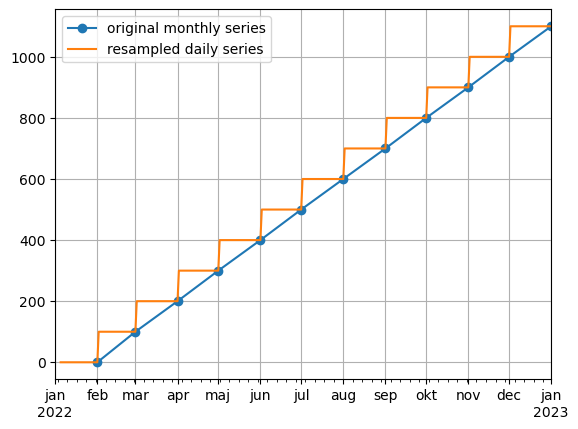

In [28]:
# define a new index
new_index = pd.date_range("2022-01-01", "2022-12-31", freq="D")

# resample to daily data
Q_daily = ps.ts.timestep_weighted_resample(Q0, new_index)

# plot the comparison
ax = Q0.plot(marker="o", label="original monthly series")
Q_daily.plot(ax=ax, label="resampled daily series")
ax.legend()
ax.grid(True)

### Example 2: Resample precipitation between 9AM-9AM to 12AM-12AM

In the Netherlands, the rainfall gauges that are measured daily measure between
9 AM one day and 9 AM the next day. For time series models with a daily
timestep it is often simpler to use time series represent one full day (from 12
AM - 12 AM). We can do this ourselved by applying the formula:
$data_{24}[t] = \frac{9}{24}data_{9}[t] + \frac{15}{24}data_{9}[t+1]$ but once again,
`timestep_weighted_resample` can help us calculate this resampled time series.
First we invent some new random data.

In [29]:
index = pd.date_range("2022-01-01 09:00:00", "2022-01-10 09:00:00")
data = np.random.rand(len(index))

p0 = pd.Series(index=index, data=data)
p0

2022-01-01 09:00:00    0.929409
2022-01-02 09:00:00    0.832596
2022-01-03 09:00:00    0.799583
2022-01-04 09:00:00    0.328890
2022-01-05 09:00:00    0.951661
2022-01-06 09:00:00    0.485500
2022-01-07 09:00:00    0.179770
2022-01-08 09:00:00    0.713940
2022-01-09 09:00:00    0.122905
2022-01-10 09:00:00    0.147496
Freq: D, dtype: float64

The result is shown below. Note how each resampled point represents the
weighted average of the two surrounding observations, which is what we want.

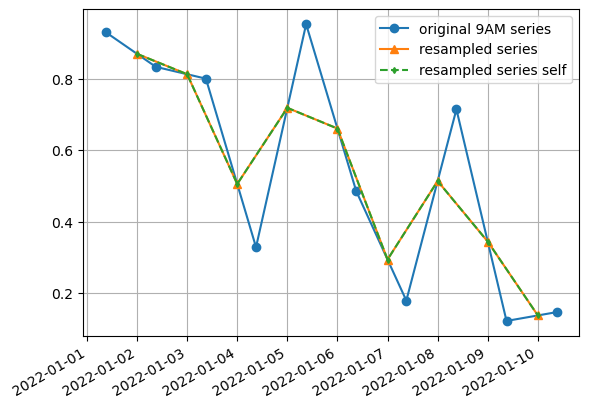

In [30]:
# create a new daily index, running from 12AM-12AM
new_index = pd.date_range(p0.index[0].normalize(), p0.index[-1].normalize())

# resample time series
p_resample = ps.ts.timestep_weighted_resample(p0, new_index)

# try it ourselves:
p_self = [
    data[i] * (h / 24) + data[i + 1] * ((24 - h) / 24)
    for i, h in enumerate(index.hour.values[1:])
]
p_resample_self = pd.Series(p_self, new_index[1:])

# plot comparison
ax = p0.plot(marker="o", label="original 9AM series")
p_resample.plot(marker="^", ax=ax, label="resampled series")
p_resample_self.plot(
    marker="d", markersize=3, linestyle="--", ax=ax, label="resampled series self"
)
ax.legend()
ax.grid(True)

### Example 3: Resample hourly data to daily data

Another frequent pre-processing step is converting hourly data to daily values.
This can be done with simple pandas methods, but `timestep_weighted_resample`
can also handle this calculation, with the added advantage of supporting
irregular time steps in the new time series.

In this example we'll simply convert an hourly time series into a daily time series.

In [31]:
# create some hourly data
index = pd.date_range("2022-01-01 00:00:00", "2022-01-03 00:00:00", freq="h")
data = np.hstack([np.arange(len(index) // 2), 24 * np.ones(len(index) // 2 + 1)])

# convert to series
p0 = pd.Series(index=index, data=data)
p0.head()

2022-01-01 00:00:00    0.0
2022-01-01 01:00:00    1.0
2022-01-01 02:00:00    2.0
2022-01-01 03:00:00    3.0
2022-01-01 04:00:00    4.0
Freq: h, dtype: float64

The result shows that the resampled value at the end of each day represents the
average value of that day, which is what we would expect.

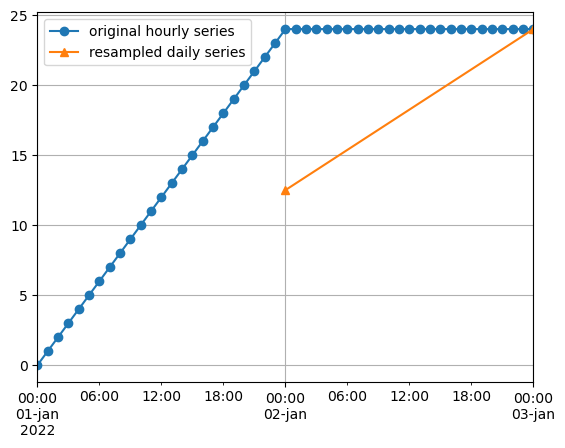

In [32]:
# create a new daily index
new_index = pd.date_range(p0.index[0].normalize(), p0.index[-1].normalize(), freq="D")

# resample measurements
p_resample = ps.ts.timestep_weighted_resample(p0, new_index)

# plot the comparison
ax = p0.plot(marker="o", label="original hourly series")
p_resample.plot(marker="^", ax=ax, label="resampled daily series")
ax.legend()
ax.grid(True)

### Creating equidistant time series for (ground)waterlevels

The following methods are used for time series that do not need to be resampled. For example, the measurements represent a state (e.g. head, water level) and either an equidistant sample is taken from the original time series, or observations are shifted slightly, to create an equidistant time series. This can be done in a number of different ways:

- `pandas_equidistant_sample` takes a sample at equidistant timesteps from the original series, at the user-specified frequency. For very irregular time series lots of observations will be lost. The advantage is that observations are not shifted in time, unlike in the other methods.
- `pandas_equidistant_nearest` creates a new equidistant index with the user-specified frequency, then `Series.reindex()` is used with `method="nearest"` which will shift certain observations in time to fill the equidistant time series. This method can introduce duplicates (i.e. an observation that is used more than once) in the final result.
- `pandas_equidistant_asfreq` rounds the series index to the user-specified frequency, then drops any duplicates before calling `Series.asfreq` with the user-specified frequency. This ensures no duplicates are contained in the resulting time series.
- `get_equidistant_timeseries_nearest` creates a equidistant time series minimizing the number of dropped points and ensuring that each observation from the original time series is used only once in the resulting equidistant time series. This method 


The different methods are compared in the following four examples.

_**Note:** in terms of performance the pandas methods are much faster._

#### Example 1

Lets create a timeseries spaced which is normally spaced with a frequency of 6
hours. The first and last measurement are shifted a bit later and earlier
respectively. 

The different methods for creating equidistant time series for levels are compared.

Text(0.5, 0, '')

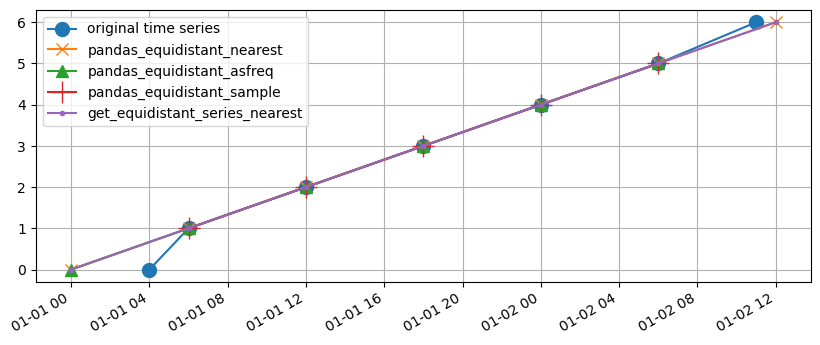

In [33]:
# Create time series
freq = "6h"
idx0 = pd.date_range("2000-01-01", freq=freq, periods=7).tolist()
idx0[0] = pd.Timestamp("2000-01-01 04:00:00")
idx0[-1] = pd.Timestamp("2000-01-02 11:00:00")
series = pd.Series(index=idx0, data=np.arange(len(idx0), dtype=float))

# Create equidistant time series with Pastas
s_pd1 = ps.ts.pandas_equidistant_sample(series, freq)
s_pd2 = ps.ts.pandas_equidistant_nearest(series, freq)
s_pd3 = ps.ts.pandas_equidistant_asfreq(series, freq)
s_pastas = ps.ts.get_equidistant_series_nearest(series, freq)

# Create figure
plt.figure(figsize=(10, 4))
ax = series.plot(
    marker="o",
    label="original time series",
    ms=10,
)
s_pd2.plot(ax=ax, marker="x", ms=8, label="pandas_equidistant_nearest")
s_pd3.plot(ax=ax, marker="^", ms=8, label="pandas_equidistant_asfreq")
s_pd1.plot(ax=ax, marker="+", ms=16, label="pandas_equidistant_sample")
s_pastas.plot(ax=ax, marker=".", label="get_equidistant_series_nearest")

ax.grid(True)
ax.legend(loc="best")
ax.set_xlabel("")

Both the `pandas_equidistant_nearest` and `pandas_equidistant_asfreq` methods and `get_equidistant_series_nearest` show the observations at the beginning and the end of the time series are shifted to the nearest equidistant timestamp. The `pandas_equidistant_sample` method drops 2 datapoints because they're measured at different time offsets.

In [34]:
# some helper functions to show differences in performance
def values_kept(s, original):
    diff = set(original.dropna().values) & set(s.dropna().values)
    return len(diff)


def n_duplicates(s):
    return (s.value_counts() >= 2).sum()

In [35]:
dfall = pd.concat([series, s_pd1, s_pd2, s_pd3, s_pastas], axis=1, sort=True)
dfall.columns = [
    "original",
    "pandas_equidistant_sample",
    "pandas_equidistant_nearest",
    "pandas_equidistant_asfreq",
    "get_equidistant_series_nearest",
]
dfall

,original,pandas_equidistant_sample,pandas_equidistant_nearest,pandas_equidistant_asfreq,get_equidistant_series_nearest
2000-01-01 00:00:00,NaN,NaN,0.0,0.0,0.0
2000-01-01 04:00:00,0.0,NaN,NaN,NaN,NaN
2000-01-01 06:00:00,1.0,1.0,1.0,1.0,1.0
2000-01-01 12:00:00,2.0,2.0,2.0,2.0,2.0
2000-01-01 18:00:00,3.0,3.0,3.0,3.0,3.0
2000-01-02 00:00:00,4.0,4.0,4.0,4.0,4.0
2000-01-02 06:00:00,5.0,5.0,5.0,5.0,5.0
2000-01-02 11:00:00,6.0,NaN,NaN,NaN,NaN
2000-01-02 12:00:00,NaN,NaN,6.0,NaN,6.0


The following table summarizes the results, showing how many values from the original time series are kept and how many duplicates are contained in the final result.

In [36]:
valueskept = dfall.apply(values_kept, args=(dfall["original"],))
valueskept.name = "values kept"
duplicates = dfall.apply(n_duplicates)
duplicates.name = "duplicates"

pd.concat([valueskept, duplicates], axis=1)

,values kept,duplicates
original,7,0
pandas_equidistant_sample,5,0
pandas_equidistant_nearest,7,0
pandas_equidistant_asfreq,6,0
get_equidistant_series_nearest,7,0


#### Example 2

Text(0.5, 0, '')

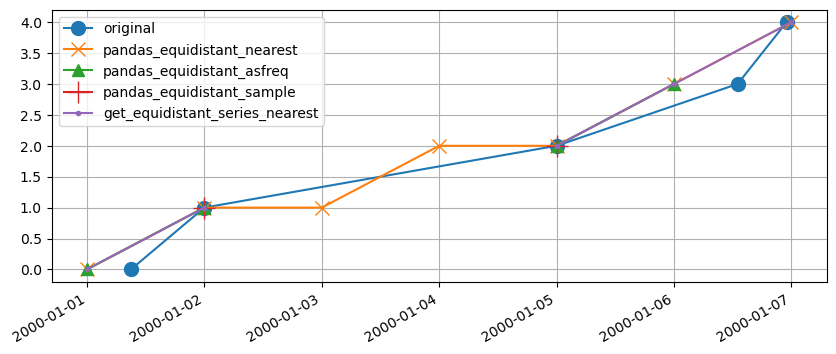

In [37]:
# Create timeseries
freq = "D"
idx0 = pd.date_range("2000-01-01", freq=freq, periods=7).tolist()
idx0[0] = pd.Timestamp("2000-01-01 09:00:00")
del idx0[2]
del idx0[2]
idx0[-2] = pd.Timestamp("2000-01-06 13:00:00")
idx0[-1] = pd.Timestamp("2000-01-06 23:00:00")
series = pd.Series(index=idx0, data=np.arange(len(idx0), dtype=float))

# Create equidistant timeseries
s_pd1 = ps.ts.pandas_equidistant_sample(series, freq)
s_pd2 = ps.ts.pandas_equidistant_nearest(series, freq)
s_pd3 = ps.ts.pandas_equidistant_asfreq(series, freq)
s_pastas = ps.ts.get_equidistant_series_nearest(series, freq)

# Create figure
plt.figure(figsize=(10, 4))
ax = series.plot(marker="o", label="original", ms=10)
s_pd2.plot(ax=ax, marker="x", ms=10, label="pandas_equidistant_nearest")
s_pd3.plot(ax=ax, marker="^", ms=8, label="pandas_equidistant_asfreq")
s_pd1.plot(ax=ax, marker="+", ms=16, label="pandas_equidistant_sample")
s_pastas.plot(ax=ax, marker=".", label="get_equidistant_series_nearest")
ax.grid(True)
ax.legend(loc="best")
ax.set_xlabel("")

In this example, the shortcomings of `pandas_equidistant_nearest` are clearly visible. It duplicates observations from the original timeseries to fill the gaps. This can be solved by passing e.g. `tolerance="0.99{freq}"` to `series.reindex()` in which case the gaps will not be filled. However, with very irregular timesteps this is not guaranteed to work and duplicates may still occur. The `pandas_equidistant_asfreq` and pastas methods work as expected and uses the available data to create a reasonable equidistant timeseries from the original data. The `pandas_equidistant_sample` method is only able to keep two observations from the original series in this example.

In [38]:
dfall = pd.concat([series, s_pd1, s_pd2, s_pd3, s_pastas], axis=1, sort=True)
dfall.columns = [
    "original",
    "pandas_equidistant_sample",
    "pandas_equidistant_nearest",
    "pandas_equidistant_asfreq",
    "get_equidistant_series_nearest",
]
dfall

,original,pandas_equidistant_sample,pandas_equidistant_nearest,pandas_equidistant_asfreq,get_equidistant_series_nearest
2000-01-01 00:00:00,NaN,NaN,0.0,0.0,0.0
2000-01-01 09:00:00,0.0,NaN,NaN,NaN,NaN
2000-01-02 00:00:00,1.0,1.0,1.0,1.0,1.0
2000-01-03 00:00:00,NaN,NaN,1.0,NaN,NaN
2000-01-04 00:00:00,NaN,NaN,2.0,NaN,NaN
2000-01-05 00:00:00,2.0,2.0,2.0,2.0,2.0
2000-01-06 00:00:00,NaN,NaN,3.0,3.0,3.0
2000-01-06 13:00:00,3.0,NaN,NaN,NaN,NaN
2000-01-06 23:00:00,4.0,NaN,NaN,NaN,NaN
2000-01-07 00:00:00,NaN,NaN,4.0,NaN,4.0


The following table summarizes the results, showing how many values from the original time series are kept and how many duplicates are contained in the final result.

In [39]:
valueskept = dfall.apply(values_kept, args=(dfall["original"],))
valueskept.name = "values kept"
duplicates = dfall.apply(n_duplicates)
duplicates.name = "duplicates"

pd.concat([valueskept, duplicates], axis=1)

,values kept,duplicates
original,5,0
pandas_equidistant_sample,2,0
pandas_equidistant_nearest,5,2
pandas_equidistant_asfreq,4,0
get_equidistant_series_nearest,5,0


#### Example 3

Text(0.5, 0, '')

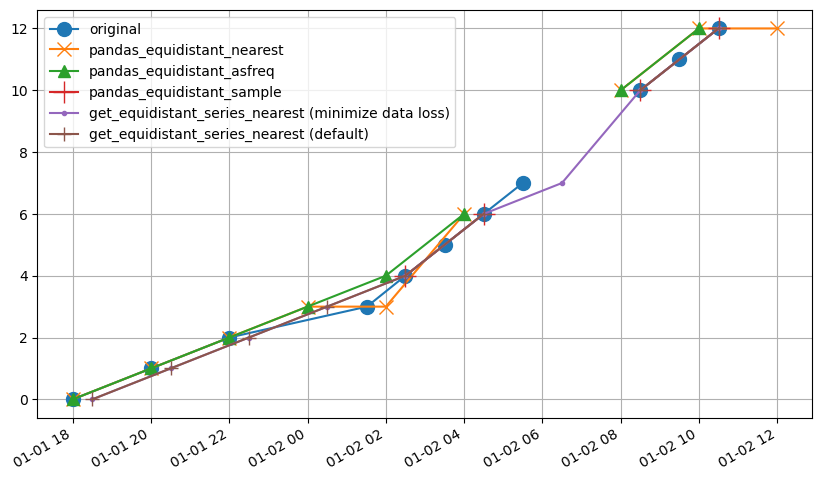

In [40]:
# Create timeseries
freq = "2h"
freq2 = "1h"
idx0 = pd.date_range("2000-01-01 18:00:00", freq=freq, periods=3).tolist()
idx1 = pd.date_range("2000-01-02 01:30:00", freq=freq2, periods=10).tolist()
idx0 = idx0 + idx1
idx0[3] = pd.Timestamp("2000-01-02 01:31:00")
series = pd.Series(index=idx0, data=np.arange(len(idx0), dtype=float))
series.iloc[8:10] = np.nan


# Create equidistant timeseries
s_pd1 = ps.ts.pandas_equidistant_sample(series, freq)
s_pd2 = ps.ts.pandas_equidistant_nearest(series, freq)
s_pd3 = ps.ts.pandas_equidistant_asfreq(series, freq)
s_pastas1 = ps.ts.get_equidistant_series_nearest(series, freq, minimize_data_loss=True)
s_pastas2 = ps.ts.get_equidistant_series_nearest(series, freq, minimize_data_loss=False)


# Create figure
plt.figure(figsize=(10, 6))
ax = series.plot(marker="o", label="original", ms=10)
s_pd2.plot(ax=ax, marker="x", ms=10, label="pandas_equidistant_nearest")
s_pd3.plot(ax=ax, marker="^", ms=8, label="pandas_equidistant_asfreq")
s_pd1.plot(ax=ax, marker="+", ms=16, label="pandas_equidistant_sample")
s_pastas1.plot(
    ax=ax, marker=".", ms=6, label="get_equidistant_series_nearest (minimize data loss)"
)
s_pastas2.plot(
    ax=ax, marker="+", ms=10, label="get_equidistant_series_nearest (default)"
)
ax.grid(True)
ax.legend(loc="best")
ax.set_xlabel("")

In this example we can observe the following behavior in each method:
- `pandas_equidistant_sample` retains 4 values.
- `pandas_equidistant_nearest` duplicates some observations in the equidistant timeseries.
- `pandas_equidistant_asfreq` does quite well, but drops some observations near the gap in the original timeseries.
- `get_equidistant_series_nearest` method misses an observation right after the gap in the original timeseries.
- `get_equidistant_series_nearest` with `minimize_data_loss=True` fills this gap, using as much data as possible from the original timeseries.

The results from the `pandas_equidistant_asfreq` and `get_equidistant_series_nearest` methods both work well, but the latter method retains more of the original data.

In [41]:
dfall = pd.concat(
    [series, s_pd1, s_pd2, s_pd3, s_pastas2, s_pastas1], axis=1, sort=True
)
dfall.columns = [
    "original",
    "pandas_equidistant_sample",
    "pandas_equidistant_nearest",
    "pandas_equidistant_asfreq",
    "get_equidistant_series_nearest (default)",
    "get_equidistant_series_nearest (minimize data loss)",
]
dfall

,original,pandas_equidistant_sample,pandas_equidistant_nearest,pandas_equidistant_asfreq,get_equidistant_series_nearest (default),get_equidistant_series_nearest (minimize data loss)
2000-01-01 18:00:00,0.0,NaN,0.0,0.0,NaN,NaN
2000-01-01 18:30:00,NaN,NaN,NaN,NaN,0.0,0.0
2000-01-01 20:00:00,1.0,NaN,1.0,1.0,NaN,NaN
2000-01-01 20:30:00,NaN,NaN,NaN,NaN,1.0,1.0
2000-01-01 22:00:00,2.0,NaN,2.0,2.0,NaN,NaN
2000-01-01 22:30:00,NaN,NaN,NaN,NaN,2.0,2.0
2000-01-02 00:00:00,NaN,NaN,3.0,3.0,NaN,NaN
2000-01-02 00:30:00,NaN,NaN,NaN,NaN,3.0,3.0
2000-01-02 01:31:00,3.0,NaN,NaN,NaN,NaN,NaN
2000-01-02 02:00:00,NaN,NaN,3.0,4.0,NaN,NaN


The following table summarizes the results, showing how many values from the original time series are kept and how many duplicates are contained in the final result.

In [42]:
valueskept = dfall.apply(values_kept, args=(dfall["original"],))
valueskept.name = "values kept"
duplicates = dfall.apply(n_duplicates)
duplicates.name = "duplicates"

pd.concat([valueskept, duplicates], axis=1)

,values kept,duplicates
original,11,0
pandas_equidistant_sample,4,0
pandas_equidistant_nearest,7,2
pandas_equidistant_asfreq,8,0
get_equidistant_series_nearest (default),8,0
get_equidistant_series_nearest (minimize data loss),9,0


#### Example 4

Text(0.5, 0, '')

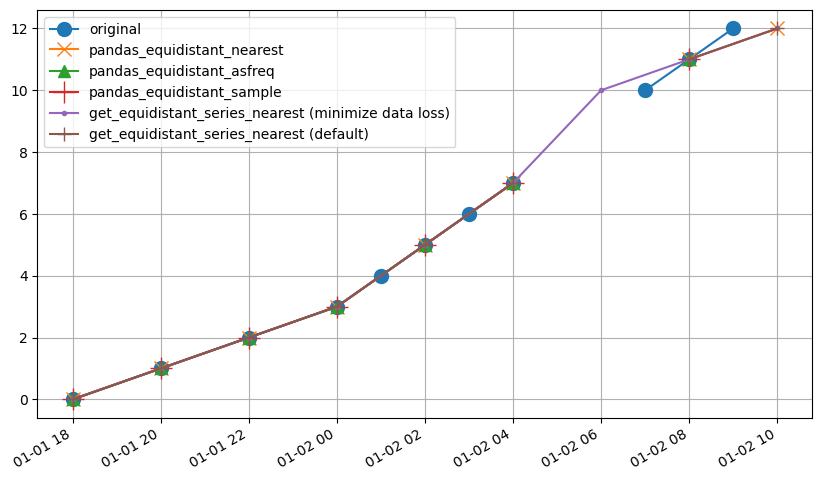

In [43]:
# Create timeseries
freq = "2h"
freq2 = "1h"
idx0 = pd.date_range("2000-01-01 18:00:00", freq=freq, periods=3).tolist()
idx1 = pd.date_range("2000-01-02 00:00:00", freq=freq2, periods=10).tolist()
idx0 = idx0 + idx1
series = pd.Series(index=idx0, data=np.arange(len(idx0), dtype=float))
series.iloc[8:10] = np.nan

# Create equidistant timeseries
s_pd1 = ps.ts.pandas_equidistant_sample(series, freq)
s_pd2 = ps.ts.pandas_equidistant_nearest(series, freq)
s_pd3 = ps.ts.pandas_equidistant_asfreq(series, freq)
s_pastas1 = ps.ts.get_equidistant_series_nearest(series, freq, minimize_data_loss=True)
s_pastas2 = ps.ts.get_equidistant_series_nearest(series, freq, minimize_data_loss=False)

# Create figure
plt.figure(figsize=(10, 6))
ax = series.plot(marker="o", label="original", ms=10)
s_pd2.plot(ax=ax, marker="x", ms=10, label="pandas_equidistant_nearest")
s_pd3.plot(ax=ax, marker="^", ms=8, label="pandas_equidistant_asfreq")
s_pd1.plot(ax=ax, marker="+", ms=16, label="pandas_equidistant_sample")
s_pastas1.plot(
    ax=ax, marker=".", ms=6, label="get_equidistant_series_nearest (minimize data loss)"
)
s_pastas2.plot(
    ax=ax, marker="+", ms=10, label="get_equidistant_series_nearest (default)"
)
ax.grid(True)
ax.legend(loc="best")
ax.set_xlabel("")

Similar to the previous example, `get_equidistant_timeseries` retains the most data from the original timeseries. In this case both the `pandas_equidistant_asfreq`  and `pandas_equidistant_nearest` methods perform well, but do omit some of the original data at the end of the timeseries or near the gap in the original timeseries.

In [44]:
dfall = pd.concat(
    [series, s_pd1, s_pd2, s_pd3, s_pastas2, s_pastas1], axis=1, sort=True
)
dfall.columns = [
    "original",
    "pandas_equidistant_sample",
    "pandas_equidistant_nearest",
    "pandas_equidistant_asfreq",
    "get_equidistant_series_nearest (default)",
    "get_equidistant_series_nearest (minimize data loss)",
]
dfall

,original,pandas_equidistant_sample,pandas_equidistant_nearest,pandas_equidistant_asfreq,get_equidistant_series_nearest (default),get_equidistant_series_nearest (minimize data loss)
2000-01-01 18:00:00,0.0,0.0,0.0,0.0,0.0,0.0
2000-01-01 20:00:00,1.0,1.0,1.0,1.0,1.0,1.0
2000-01-01 22:00:00,2.0,2.0,2.0,2.0,2.0,2.0
2000-01-02 00:00:00,3.0,3.0,3.0,3.0,3.0,3.0
2000-01-02 01:00:00,4.0,NaN,NaN,NaN,NaN,NaN
2000-01-02 02:00:00,5.0,5.0,5.0,5.0,5.0,5.0
2000-01-02 03:00:00,6.0,NaN,NaN,NaN,NaN,NaN
2000-01-02 04:00:00,7.0,7.0,7.0,7.0,7.0,7.0
2000-01-02 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-02 06:00:00,NaN,NaN,NaN,NaN,NaN,10.0


The following table summarizes the results, showing how many values from the original time series are kept and how many duplicates are contained in the final result.

In [45]:
valueskept = dfall.apply(values_kept, args=(dfall["original"],))
valueskept.name = "values kept"
duplicates = dfall.apply(n_duplicates)
duplicates.name = "duplicates"

pd.concat([valueskept, duplicates], axis=1)

,values kept,duplicates
original,11,0
pandas_equidistant_sample,7,0
pandas_equidistant_nearest,8,0
pandas_equidistant_asfreq,7,0
get_equidistant_series_nearest (default),8,0
get_equidistant_series_nearest (minimize data loss),9,0
